# 美国国债收益率曲线 PCA 初步诊断

本 Notebook 使用 2Y、5Y、10Y、30Y 的日收益率变化（单位：bp），回答五个问题：

1. 前几个主成分能解释多少曲线波动？
2. PC1、PC2、PC3 的 loading 是否类似 level、slope、curvature？
3. PC scores 随时间怎样变化？
4. 使用 1、2、3 个 PC 重建曲线时误差多大？
5. 不同历史阶段的 PCA loading 是否稳定？

这里先做研究诊断，不训练预测模型，也不构造交易仓位。

## 1. 导入依赖并定位项目目录

Notebook 位于 `notebook/`，所以项目根目录是其上一级。

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data/processed/treasury_yield_changes_bp.csv"

print("Project root:", PROJECT_ROOT)
print("Data exists:", DATA_PATH.exists())

Project root: c:\Users\蒋大王\Desktop\量化\Interest_rate_investment
Data exists: True


## 2. 读取2006年以来的连续样本

每行代表一个交易日，每列代表一个期限的收益率变化。收益率变化的单位是 bp。

In [2]:
MATURITIES = ["2Y", "5Y", "10Y", "30Y"]
CHANGE_COLUMNS = [f"d_{maturity}_bp" for maturity in MATURITIES]
SAMPLE_START = pd.Timestamp("2006-02-10")

changes = pd.read_csv(DATA_PATH, parse_dates=["date"])
sample = (
    changes.loc[changes["date"] >= SAMPLE_START, ["date", *CHANGE_COLUMNS]]
    .sort_values("date")
    .reset_index(drop=True)
)

print("Shape:", sample.shape)
print("Date range:", sample["date"].min().date(), "to", sample["date"].max().date())
display(sample.head())
display(sample.tail())

Shape: (5161, 5)
Date range: 2006-02-10 to 2026-09-25


,date,d_2Y_bp,d_5Y_bp,d_10Y_bp,d_30Y_bp
0,2006-02-10,3.0000,4.0000,5.0000,4.0000
1,2006-02-13,-1.0000,-1.0000,-1.0000,1.0000
2,2006-02-14,1.0000,3.0000,4.0000,4.0000
3,2006-02-15,2.0000,-1.0000,-1.0000,-2.0000
4,2006-02-16,-2.0000,-1.0000,-2.0000,-1.0000


,date,d_2Y_bp,d_5Y_bp,d_10Y_bp,d_30Y_bp
5156,2026-09-21,0.0000,-3.0000,-5.0000,-5.0000
5157,2026-09-22,-5.0000,0.0000,0.0000,0.0000
5158,2026-09-23,14.0000,16.0000,15.0000,11.0000
5159,2026-09-24,2.0000,4.0000,7.0000,7.0000
5160,2026-09-25,-6.0000,-5.0000,-1.0000,2.0000


## 3. PCA 前的最后检查

PCA 不能直接处理缺失值。这里确认样本没有缺失、重复日期或错误排序。

In [3]:
checks = pd.Series({
    "missing_values": int(sample[CHANGE_COLUMNS].isna().sum().sum()),
    "duplicate_dates": int(sample["date"].duplicated().sum()),
    "dates_increasing": sample["date"].is_monotonic_increasing,
    "maximum_gap_days": int(sample["date"].diff().dt.days.max()),
})
display(checks.to_frame("result"))
display(sample[CHANGE_COLUMNS].describe().T)

,result
missing_values,0
duplicate_dates,0
dates_increasing,True
maximum_gap_days,4


,count,mean,std,min,25%,50%,75%,max
d_2Y_bp,"5,161.0000",0.0029,5.1772,-57.0000,-2.0000,0.0000,2.0000,38.0000
d_5Y_bp,"5,161.0000",0.0083,5.8965,-46.0000,-3.0000,0.0000,3.0000,34.0000
d_10Y_bp,"5,161.0000",0.0122,5.6909,-51.0000,-3.0000,0.0000,3.0000,29.0000
d_30Y_bp,"5,161.0000",0.0190,5.3939,-32.0000,-3.0000,0.0000,3.0000,29.0000


## 4. 划分训练期并拟合 PCA

第一版使用 **2006-02-10 至 2019-12-31** 作为 PCA 训练期。2020 年以后的数据不参与拟合，暂时只作为样本外诊断数据。这样可以观察训练期学到的主成分结构在后续时期是否仍然稳定。

### 4.1 构造训练矩阵

```python
X_train = sample.loc[train_mask, CHANGE_COLUMNS].to_numpy()
```

`X_train` 的每一行代表一个交易日，每一列依次代表 2Y、5Y、10Y、30Y 的单日收益率变化，单位为 bp，to_numpy() 把 DataFrame 转换为 NumPy array取消掉行列名：

```text
[
    [ 3.0,  4.0,  5.0,  4.0],
    [-1.0, -1.0, -1.0,  1.0],
    [ 1.0,  3.0,  4.0,  4.0],
    ...
]
```

`sklearn.PCA` 会先减去训练期内每个期限变化的均值，但不会再除以各期限的标准差。因此这里做的是 **covariance PCA（协方差矩阵 PCA）**，四个期限都保留相同的 bp 单位。

### 4.2 `fit()` 学到了什么

```python
pca.fit(X_train)
```

`fit()` 只使用训练期数据学习 PCA 坐标系，主要得到：

- `pca.mean_`：训练期内四个期限变化的均值，用于中心化。
- `pca.components_`：各主成分的 loading（载荷），也就是 PCA 坐标轴的方向。每一行对应一个主成分。
- `pca.explained_variance_`：每个主成分 score 的方差。
- `pca.explained_variance_ratio_`：每个主成分解释的方差占总方差的比例。

例如，假设训练后 PC1 的 loading 为：

$$
l_1=
\begin{bmatrix}
0.39 & 0.56 & 0.55 & 0.49
\end{bmatrix}
$$

四个系数都是正数且大小接近，说明 2Y、5Y、10Y、30Y 倾向于同方向变化，所以 PC1 通常被解释为收益率曲线的 **level（整体水平）** 因子。

### 4.3 `transform()` 如何得到 score

```python
scores_all = pca.transform(X_all)
```

`transform()` 不会重新学习 loading。它使用 `fit()` 已经学到的训练期均值和 loading，把每一天的四期限变化投影到各条主成分轴上。第 $t$ 天在第 $k$ 个主成分上的 score 为：

$$
\text{score}_{t,k}
=
(\Delta y_t-\bar{\Delta y}_{\text{train}})\cdot l_k
$$

其中，$\Delta y_t$ 是当天四个期限的变化，$\bar{\Delta y}_{\text{train}}$ 是训练期均值，$l_k$ 是第 $k$ 个主成分的 loading。**score 是当天变化在该主成分方向上的坐标，也可以理解为当天该因子的实现值或强度。**

例如，若某天中心化后的收益率变化近似为：

$$
\Delta y_t-\bar{\Delta y}_{\text{train}}
=
\begin{bmatrix}
5 & 6 & 6 & 5
\end{bmatrix}
$$

那么它的 PC1 score 约为：

$$
\text{PC1 score}
\approx
5(0.39)+6(0.56)+6(0.55)+5(0.49)
$$

这个 score 较大且为正，表示当天四个期限普遍上升，并且这种变化与 PC1 的整体水平上升方向高度一致。若 score 为负，则表示当天主要沿 PC1 的反方向移动，即整体利率下降。

如果某天的变化为短端上升、长端下降，例如：

$$
\begin{bmatrix}
10 & 4 & -3 & -8
\end{bmatrix}
$$

这种形状通常与表示曲线斜率变化的 PC2 更相似，因此 PC2 score 的绝对值可能较大。具体正负号取决于 PC2 loading 的符号方向；PCA 的整体符号本身可以翻转，不影响经济含义。

对全部观测一次性计算时，矩阵形式为：

```python
scores_all = (X_all - pca.mean_) @ pca.components_.T
```

这与 `pca.transform(X_all)` 等价。注意 `components_` 中每一行是一条 loading，因此矩阵相乘时需要使用转置 `.T`。

一句话总结：**`fit()` 用训练数据学习均值和主成分方向；`transform()` 使用这些已学好的方向，计算每一天在 PC1、PC2、PC3、PC4 上的 score。**

In [ ]:
TRAIN_END = pd.Timestamp("2019-12-31")
train_mask = sample["date"] <= TRAIN_END

X_train = sample.loc[train_mask, CHANGE_COLUMNS].to_numpy()
X_all = sample[CHANGE_COLUMNS].to_numpy()

pca = PCA(n_components=4)
pca.fit(X_train)
scores_all = pca.transform(X_all)

print("Training observations:", len(X_train))
print("PCA training end:", TRAIN_END.date())

Training observations: 3476
PCA training end: 2019-12-31


## 5. 解释方差

解释方差比例表示每个 PC 能解释原始四期限共同波动的多少。累计解释方差用于判断保留两个还是三个 PC。

,explained_variance_pct,cumulative_pct
PC1,87.1300,87.1300
PC2,10.3200,97.4500
PC3,1.9400,99.3900
PC4,0.6100,100.0000


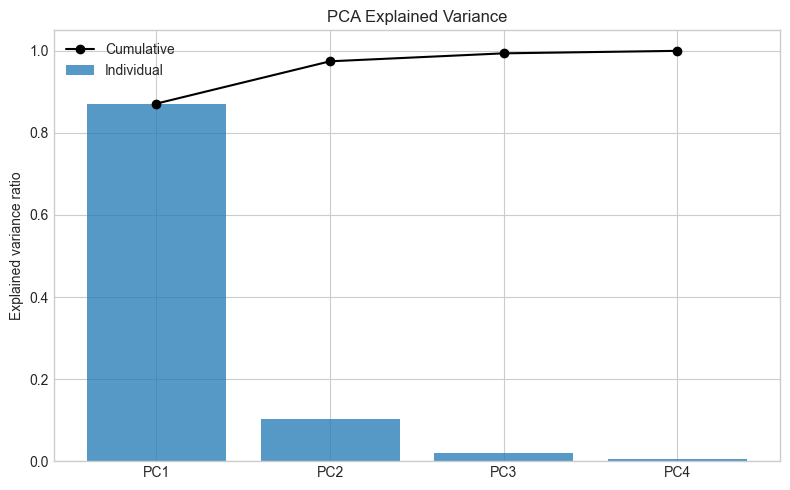

In [5]:
pc_names = [f"PC{i}" for i in range(1, 5)]
explained = pd.DataFrame({
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_ratio": np.cumsum(pca.explained_variance_ratio_),
}, index=pc_names)
explained_display = (explained * 100).round(2)
explained_display.columns = ["explained_variance_pct", "cumulative_pct"]
display(explained_display)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(pc_names, explained["explained_variance_ratio"], alpha=0.75, label="Individual")
ax.plot(pc_names, explained["cumulative_ratio"], marker="o", color="black", label="Cumulative")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Explained variance ratio")
ax.set_title("PCA Explained Variance")
ax.legend()
plt.tight_layout()
plt.show()

## 6. 查看 loadings

每一行是一个 PC，每一列是一个期限。Loading 描述的是：当某个 PC 的 score 增加 1 个单位时，2Y、5Y、10Y、30Y 收益率分别沿什么方向、以多大相对幅度变化。

PCA 向量的整体正负号是任意的。例如，一组 loading 和它整体乘以 -1 表示同一条轴，只是 score 的正负也会同时翻转。因此，解释时重点看各期限之间的**相对符号和曲线形状**，而不是机械地认为某个 PC 天生必须为正或为负。

### 6.1 PC1：Level（整体水平）

本样本中 PC1 的 loading 约为：

$$
l_1=
\begin{bmatrix}
0.3867 & 0.5575 & 0.5506 & 0.4864
\end{bmatrix}
$$

四个期限全部同号且数值相近，说明 PC1 主要描述整条收益率曲线近似平行上移或下移，因此通常称为 **level factor**。按照当前 loading 的符号，PC1 score 为正表示各期限收益率整体上升；PC1 score 为负表示整体下降。

与之对应的是 **duration trade（久期方向交易）**。PC1 本身不是 duration：PC1 描述收益率整体移动了多少，而 duration 或 DV01 描述债券价格对这种收益率移动有多敏感。近似关系为：

$$
\frac{\Delta P}{P}\approx-D_{\text{mod}}\Delta y
$$

因此，做多 duration 通常意味着持有债券或接收固定利率，押注收益率下降、债券价格上涨；做空 duration 则押注收益率上升。PC1 是 duration trade 最主要的收益率风险来源。

收益率曲线的 level 可以用四个期限的平均变化粗略代理：

$$
\Delta L_t=\frac{\Delta y_{2Y,t}+\Delta y_{5Y,t}+\Delta y_{10Y,t}+\Delta y_{30Y,t}}{4}
$$

而 PCA 使用数据估计出的 loading 加权：

$$
\text{PC1 score}_t=l_1^\top\Delta y_t
$$

### 6.2 PC2：Slope（曲线斜率）

本样本中 PC2 的 loading 约为：

$$
l_2=
\begin{bmatrix}
0.7100 & 0.2759 & -0.2500 & -0.5977
\end{bmatrix}
$$

短端为正、长端为负，说明 PC2 描述短端和长端的相对运动，因此通常称为 **slope factor**。曲线斜率可以用长短端利差粗略代理：

$$
\text{Slope}=y_{30Y}-y_{2Y}
$$

按照当前 loading 的符号，PC2 score 为正时短端收益率上升、长端收益率下降，长短端利差缩小，属于 **flattening（曲线变平）**；PC2 score 为负时则属于 **steepening（曲线变陡）**。如果 PCA 将整条 PC2 loading 翻转，score 的正负解释也会随之翻转。

对应的交易是 **flattener / steepener**。交易者同时持有短端和长端的相反头寸，并通常按 DV01 调整名义本金，以尽量抵消整体 level 或 duration 风险，主要保留对斜率变化的暴露。

### 6.3 PC3：Curvature（曲率）

本样本中 PC3 的 loading 约为：

$$
l_3=
\begin{bmatrix}
-0.5619 & 0.5627 & 0.2935 & -0.5306
\end{bmatrix}
$$

2Y、30Y 两端为负，5Y、10Y 中间期限为正，说明 PC3 描述曲线中部相对于两端的弯曲程度，因此通常称为 **curvature factor**。按照当前符号，PC3 score 为正表示中间期限收益率相对于两端上升，即曲线中腹向上鼓起；score 为负表示中间期限相对于两端下降。

传统的三点曲率指标可以写成：

$$
\text{Curvature}_{2s5s10s}=2y_{5Y}-y_{2Y}-y_{10Y}
$$

它比较中间的 5Y 是否偏离 2Y 和 10Y 两翼形成的近似直线。对应的交易称为 **butterfly trade（蝶式交易）**：中间期限称为 body，两侧期限称为 wings。交易者交易 body 相对于 wings 的贵贱或收益率偏离，并通常调整三条腿的 DV01，使组合尽量降低 level 和 slope 风险、主要保留 curvature 风险。

PCA curvature 与传统 butterfly 的思想相同，但权重不同：传统 fly 预先指定三个期限和类似 $[-1,2,-1]$ 的收益率权重；PCA 则根据历史协方差，从四个期限中自动学习曲率方向。实际债券交易的名义本金也不能直接照抄 PCA loading，还需要根据各工具的 DV01、价格和合约特征换算。

### 6.4 三个因子与交易的对应关系

| PCA 因子 | 曲线形状 | 粗略收益率指标 | 典型交易 | 主要押注 |
|---|---|---|---|---|
| PC1 Level | 各期限同方向移动 | 各期限收益率的平均或 PC1 score | Duration trade | 整体利率上升或下降 |
| PC2 Slope | 短端与长端相对移动 | $y_{30Y}-y_{2Y}$ | Flattener / Steepener | 曲线变平或变陡 |
| PC3 Curvature | 中间期限相对两端移动 | $2y_{5Y}-y_{2Y}-y_{10Y}$ | Butterfly trade | 中腹相对两翼变贵或变便宜 |

一句话概括：**Level 看整条曲线上下移动；slope 看左端和右端的相对移动；curvature 看中间和两端的相对移动。Loading 定义因子形状，score 表示某一天沿该形状移动了多少，DV01 则把收益率变化转换成实际交易的价格损益。**

,2Y,5Y,10Y,30Y
PC1,0.3867,0.5575,0.5506,0.4864
PC2,0.7100,0.2759,-0.2500,-0.5977
PC3,-0.5619,0.5627,0.2935,-0.5306
PC4,0.1750,-0.5445,0.7404,-0.3531


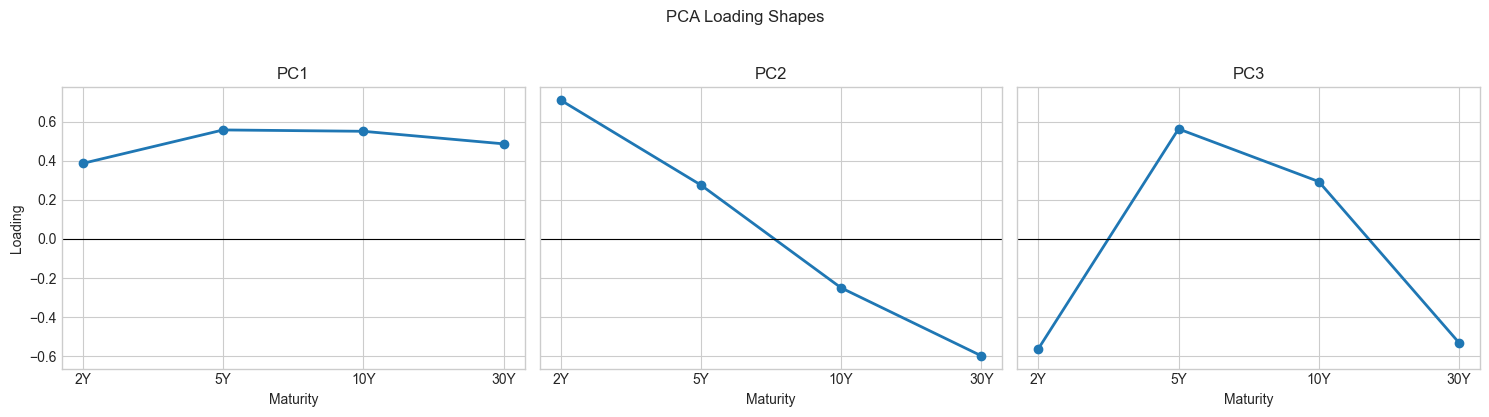

In [6]:
loadings = pd.DataFrame(
    pca.components_,
    index=pc_names,
    columns=MATURITIES,
)
display(loadings)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for index, ax in enumerate(axes):
    pc_name = pc_names[index]
    ax.plot(MATURITIES, loadings.loc[pc_name], marker="o", linewidth=2)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(pc_name)
    ax.set_xlabel("Maturity")
axes[0].set_ylabel("Loading")
fig.suptitle("PCA Loading Shapes", y=1.03)
plt.tight_layout()
plt.show()

## 7. PC scores 时间序列

Loading 描述因子的形状，score 描述每天沿该形状移动了多少。
- scores_all 是一个 NumPy 矩阵，形式类似：
[
    [ PC1分数, PC2分数, PC3分数, PC4分数 ],
    [ PC1分数, PC2分数, PC3分数, PC4分数 ],
    ...
]
每一行代表一个交易日，每一列代表一个 PC。
假设某一天得到：
[8.0, -2.0, 1.0, 0.2]
可以理解为：
- PC1 score = 8：当天主要存在较强的整体利率上升；
- PC2 score = -2：同时存在较小的曲线斜率变化；
- PC3 score = 1：还有很小的曲率变化；
- PC4 score = 0.2：剩余的高阶变化很弱。

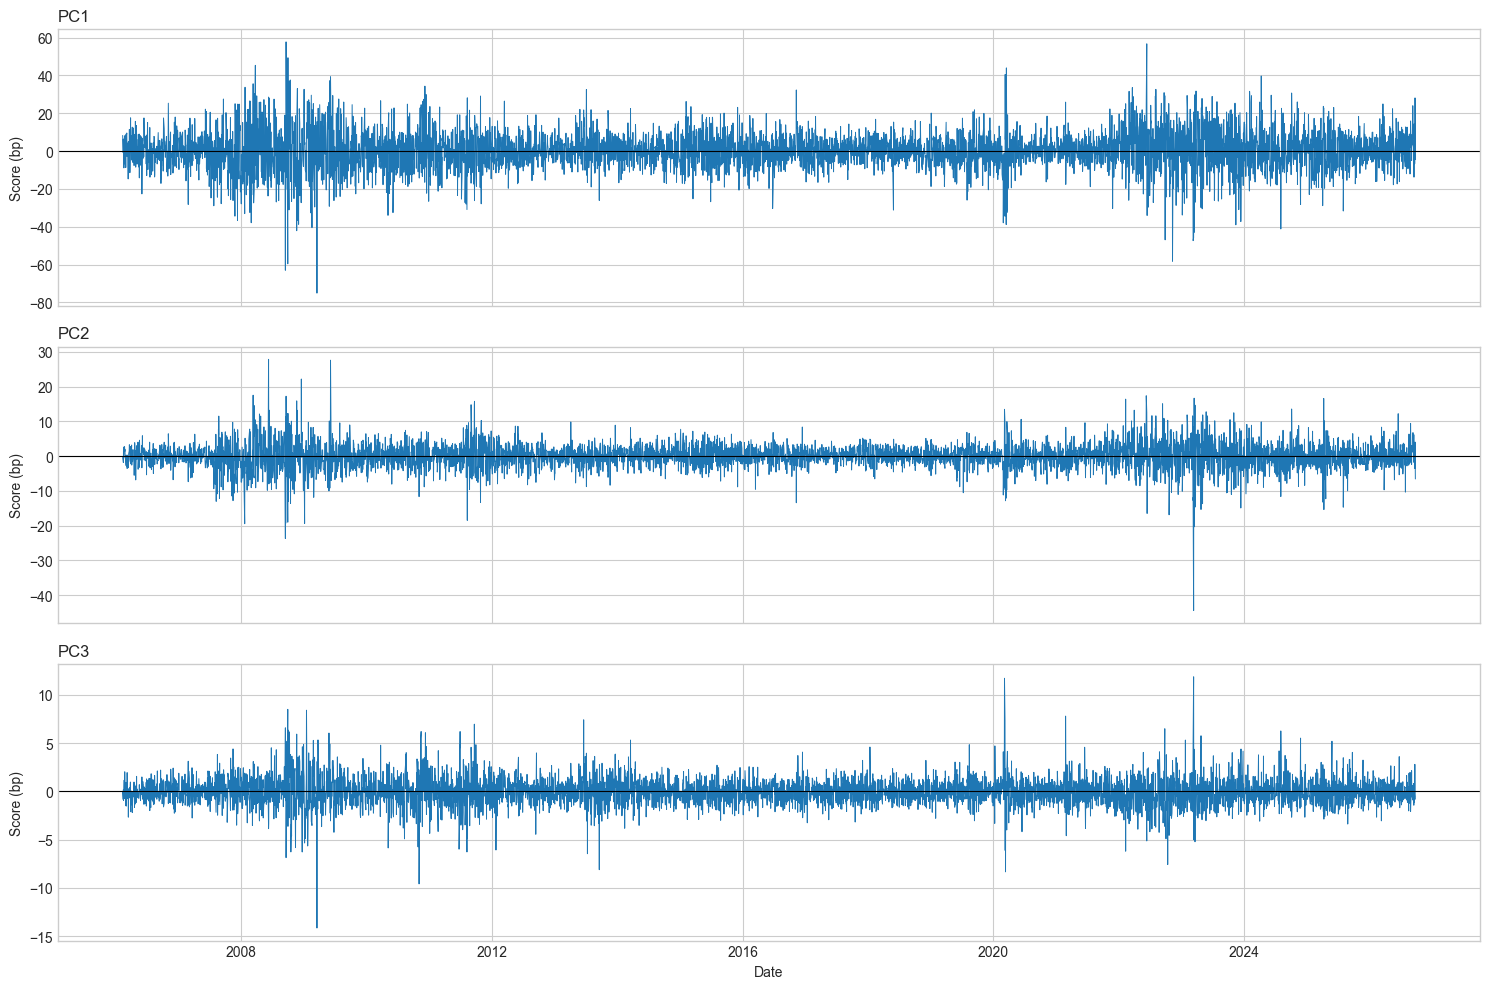

In [7]:
scores = pd.DataFrame(scores_all, columns=pc_names)
scores.insert(0, "date", sample["date"].to_numpy())

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
for pc_name, ax in zip(pc_names[:3], axes):
    ax.plot(scores["date"], scores[pc_name], linewidth=0.7)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Score (bp)")
    ax.set_title(pc_name, loc="left")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## 8. 比较 1、2、3、4 个 PC 的重建误差

这一部分检查：只保留前几个主成分时，能否准确还原每天 2Y、5Y、10Y、30Y 的收益率变化。

### 8.1 `transform()` 与 `inverse_transform()`

`transform()` 把一天的四期限收益率变化转换为该日在四条 PCA 轴上的坐标：

```text
2Y、5Y、10Y、30Y 的收益率变化
                ↓ transform
PC1、PC2、PC3、PC4 scores
```

矩阵形式为：

$$
F=(X-\mu)V^\top
$$

其中，$X$ 是四期限收益率日变化，$\mu$ 是 `pca.mean_` 保存的训练期均值，$V$ 是 `pca.components_` 保存的 loading 矩阵，$F$ 是 PC scores。

`inverse_transform()` 则进行反方向转换：它使用每天的 scores 和训练期学到的 loadings，把 PCA 坐标重新转换为四期限收益率变化：

```text
PC1、PC2、PC3、PC4 scores
             ↓ inverse_transform
2Y、5Y、10Y、30Y 的重建收益率变化
```

对应公式为：

$$
\widehat X=FV+\mu
$$

因此：

```python
reconstructed = pca.inverse_transform(scores)
```

等价于：

```python
reconstructed = scores @ pca.components_ + pca.mean_
```

这里必须加回 `pca.mean_`，因为 `transform()` 在计算 score 前先减去了训练期内每个期限的平均日变化。

### 8.2 一天的收益率变化如何被重建

假设某天四个 scores 分别为 $s_1,s_2,s_3,s_4$，对应的 loading 为 $l_1,l_2,l_3,l_4$，那么当天重建出的收益率变化为：

$$
\widehat{\Delta y}_t
=\mu+s_{1,t}l_1+s_{2,t}l_2+s_{3,t}l_3+s_{4,t}l_4
$$

其中，每一项都代表一种曲线运动对当天四期限变化的贡献：

- $s_{1,t}l_1$：当天的 level 贡献；
- $s_{2,t}l_2$：当天的 slope 贡献；
- $s_{3,t}l_3$：当天的 curvature 贡献；
- $s_{4,t}l_4$：当天剩余高阶形状的贡献。

所以，`inverse_transform()` 的确是在用**这一天的 scores × 各自的 loadings**，再加回训练期均值，变回这一天 2Y、5Y、10Y、30Y 的收益率变化，单位仍然是 bp。这里重建的是收益率的**日变化**，不是收益率水平。

### 8.3 为什么把部分 scores 设为 0

为了检查前 $k$ 个 PC 能解释多少信息，代码先创建一个与 `scores_all` 同形状的零矩阵，然后只复制前 $k$ 列：

```python
truncated_scores = np.zeros_like(scores_all)
truncated_scores[:, :n_components] = scores_all[:, :n_components]
```

例如，某天的完整 score 为：

```text
[10, 3, 2, 0.5]
```

只保留不同数量 PC 时会变成：

```text
保留1个PC：[10, 0, 0, 0]
保留2个PC：[10, 3, 0, 0]
保留3个PC：[10, 3, 2, 0]
保留4个PC：[10, 3, 2, 0.5]
```

只保留 PC1 时，重建值只包含整体水平运动；加入 PC2 后同时包含斜率运动；加入 PC3 后又包含曲率运动。保留的 PC 越多，通常越接近真实的四期限变化。

### 8.4 重建误差

重建残差定义为：

$$
e_t=\Delta y_t-\widehat{\Delta y}_t
$$

代码使用 MAE 和 RMSE 衡量真实变化与重建变化之间的差距。误差越小，说明保留的 PC 越能概括原始曲线变化；RMSE 对少数较大的重建误差惩罚更重。

当四个 PC 全部保留时，PCA 只是在两个完整坐标系之间转换，没有丢失信息，因此理论上可以完整还原原始数据，重建误差应当接近 0。

,MAE_bp,RMSE_bp
n_components,,
1,1.3728,2.0442
2,0.6105,0.8497
3,0.2661,0.4030
4,0.0000,0.0000


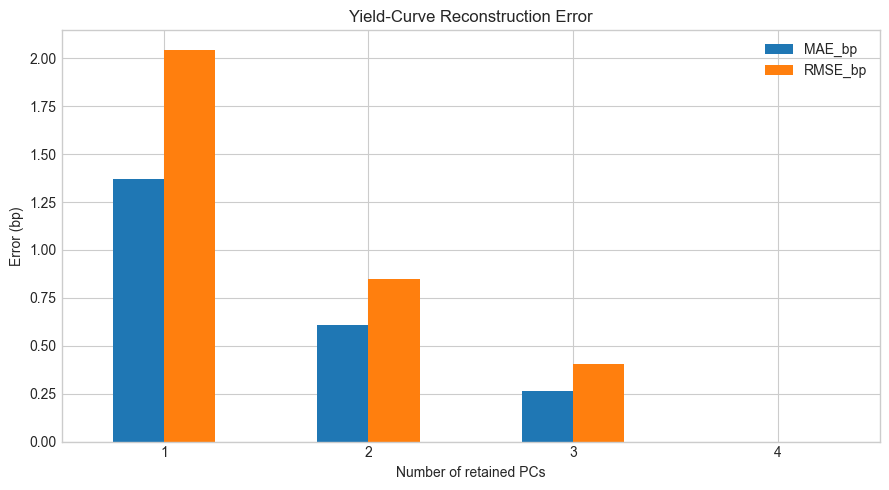

In [8]:
reconstruction_rows = []
reconstructed_by_k = {}

for n_components in range(1, 5):
    truncated_scores = np.zeros_like(scores_all)
    truncated_scores[:, :n_components] = scores_all[:, :n_components]
    reconstructed = pca.inverse_transform(truncated_scores)
    reconstructed_by_k[n_components] = reconstructed

    reconstruction_rows.append({
        "n_components": n_components,
        "MAE_bp": mean_absolute_error(X_all, reconstructed),
        "RMSE_bp": mean_squared_error(X_all, reconstructed) ** 0.5,
    })

reconstruction_summary = pd.DataFrame(reconstruction_rows).set_index("n_components")
display(reconstruction_summary)

reconstruction_summary.plot(kind="bar", figsize=(9, 5))
plt.title("Yield-Curve Reconstruction Error")
plt.xlabel("Number of retained PCs")
plt.ylabel("Error (bp)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. 各期限的三因子重建误差

整体误差可能掩盖某个期限较难重建，因此单独检查每一列。

In [9]:
reconstructed_3pc = reconstructed_by_k[3]
maturity_errors = []

for column_index, maturity in enumerate(MATURITIES):
    actual = X_all[:, column_index]
    predicted = reconstructed_3pc[:, column_index]
    maturity_errors.append({
        "maturity": maturity,
        "MAE_bp": mean_absolute_error(actual, predicted),
        "RMSE_bp": mean_squared_error(actual, predicted) ** 0.5,
        "correlation": np.corrcoef(actual, predicted)[0, 1],
    })

maturity_error_table = pd.DataFrame(maturity_errors).set_index("maturity")
display(maturity_error_table)

,MAE_bp,RMSE_bp,correlation
maturity,,,
2Y,0.1027,0.1410,0.9996
5Y,0.3196,0.4388,0.9972
10Y,0.4347,0.5968,0.9945
30Y,0.2073,0.2846,0.9986


## 10. 分阶段检查 loading 稳定性

分别在三个时期独立拟合 PCA。因为 PCA 符号可以翻转，代码会把各阶段 loading 的符号对齐到全训练期 loading，再进行比较。这里先做基础的符号对齐，不处理 PC 互换或更一般的旋转。

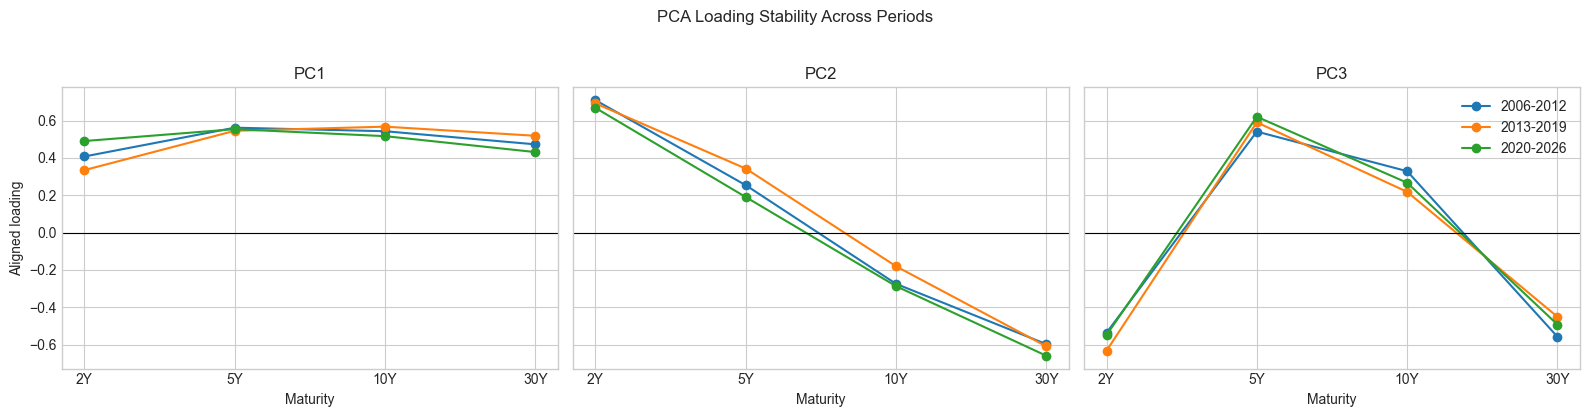

In [10]:
PERIODS = {
    "2006-2012": ("2006-02-10", "2012-12-31"),
    "2013-2019": ("2013-01-01", "2019-12-31"),
    "2020-2026": ("2020-01-01", sample["date"].max()),
}

reference_loadings = pca.components_
period_loadings = {}

for period_name, (period_start, period_end) in PERIODS.items():
    period_mask = sample["date"].between(pd.Timestamp(period_start), pd.Timestamp(period_end))
    period_X = sample.loc[period_mask, CHANGE_COLUMNS].to_numpy()
    period_pca = PCA(n_components=4).fit(period_X)
    aligned = period_pca.components_.copy()

    for pc_index in range(4):
        if np.dot(aligned[pc_index], reference_loadings[pc_index]) < 0:
            aligned[pc_index] *= -1

    period_loadings[period_name] = aligned

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for pc_index, ax in enumerate(axes):
    for period_name, aligned in period_loadings.items():
        ax.plot(MATURITIES, aligned[pc_index], marker="o", label=period_name)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"PC{pc_index + 1}")
    ax.set_xlabel("Maturity")
axes[0].set_ylabel("Aligned loading")
axes[-1].legend()
fig.suptitle("PCA Loading Stability Across Periods", y=1.03)
plt.tight_layout()
plt.show()